**Packages and Plots Standards**

In [6]:
pip install dcor

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.6/44.6 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 4.0 MB/s eta 0:00:00


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from scipy.stats import norm, kstest
import matplotlib.patches as patches
from statsmodels.tsa.stattools import ccf
import seaborn as sns
from sklearn.feature_selection import mutual_info_regression
from dcor import distance_correlation
from statsmodels.tsa.stattools import grangercausalitytests
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tsa.stattools import acf
from scipy.stats import spearmanr

In [8]:
plt.rcParams.update({
'text.usetex':        False,
'font.family': 'serif',
'font.serif': ['CMU Serif', 'DejaVu Serif'],
'mathtext.fontset': 'cm',
'font.size': 10,
"axes.labelsize": 10,
"axes.titlesize": 12,
"legend.fontsize": 10,
"xtick.labelsize": 10,
"ytick.labelsize": 10
})

In [9]:
textwidth_in  = 345.0 / 72.27   # your textwidth
textheight_in = 550 / 72.27  # replace with \the\textheight output

In [37]:
df = pd.read_csv('CombinedDatasetLongUnsmooth.csv')

**Target Feature**

In [39]:
def feature_analysis_target(feature = ["AMOC"]):
    fig, axes = plt.subplots(1, 2, figsize=(textwidth_in * 2, textwidth_in * 0.9))
    axes = axes.flatten()
    values = df[feature]
    mean_val = np.mean(values)
    std_val = np.std(values)

    for j in range(1):
        ax_ts = axes[j * 2]
        ax_ts.plot(values, color = "gray", alpha = 1.0)
        ax_ts.set_title(f'{feature[0]} — Time Series')
        ax_ts.tick_params(axis = 'x', rotation = 45)
        ax_ts.grid(alpha = 0.3)
        ax_hist = axes[j * 2 + 1]
        ax_hist.hist(values, bins = 50, color = "gray", alpha = 1.0, density = True)
        xmin, xmax = ax_hist.get_xlim()
        x = np.linspace(xmin, xmax, 100)
        ax_hist.set_title(f'{feature[0]} — Distribution')
        ax_hist.tick_params(axis = 'x', rotation = 45)
        ax_hist.grid(alpha = 0.3)

    plt.tight_layout()
    plt.savefig('target_feature_plots.pdf', bbox_inches = 'tight', dpi = 300)
    plt.show()

    return mean_val, std_val

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3800: FutureWarning: The behavior of DataFrame.std with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return std(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)


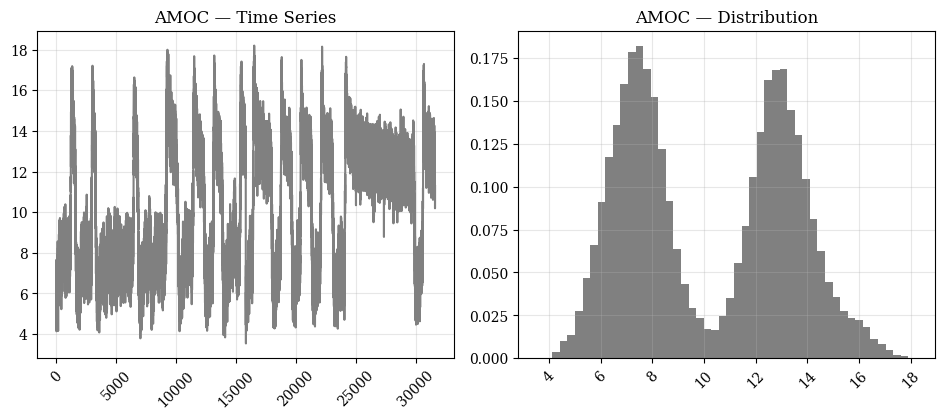

In [38]:
mean_val, std_val = feature_analysis_target()

# **Multi-Gaussian Fitting**

In [12]:
def multi_gaussian_fit(feature, color, precision = 4, leg_pos = "best"):
    data = df[feature].dropna().values.reshape(-1, 1)
    scaler = StandardScaler()
    amoc_scaled = scaler.fit_transform(data)
    gmm = GaussianMixture(n_components = 2, covariance_type = 'full', n_init = 20, random_state = 17)
    gmm.fit(amoc_scaled)
    means_scaled = gmm.means_
    means = scaler.inverse_transform(means_scaled).flatten()
    stds = np.sqrt(gmm.covariances_.flatten()) * scaler.scale_[0]
    weights = gmm.weights_

    idx = np.argsort(means)
    means = means[idx]
    stds = stds[idx]
    weights = weights[idx]

    def gaussian_separation(means, stds):

        return (abs(means[1] - means[0]) / np.sqrt((stds[0]**2 + stds[1]**2) / 2))

    print("S:", gaussian_separation(means, stds))

    for i in range(2):
        print(f"Component {i+1}: " f"weight={weights[i]:.3f}, "
              f"mean={means[i]:.6e}, " f"std={stds[i]:.6e}")

    fig, axes = plt.subplots(2, 1, figsize = (textwidth_in, textheight_in * 0.9), sharex = True)
    ax1 = axes[0]
    ax1.hist(data.flatten(), bins = 50, density = True, color = color, label = f'{feature} Histogram')

    x = np.linspace(data.min(), data.max(), 5000)
    X_plot = x.reshape(-1, 1)
    X_scaled = scaler.transform(X_plot)
    pdf_scaled = np.exp(gmm.score_samples(X_scaled))
    pdf = pdf_scaled / scaler.scale_[0]
    ax1.plot(x, pdf, color = "black", lw = 3, label = "GMM Fit")
    pdf_colors = ["purple", "green"]

    for i in range(2):
        component_pdf = (weights[i] * norm.pdf(x, means[i], stds[i]))
        ax1.plot(x, component_pdf, '--', color = pdf_colors[i], lw = 2, label = (f'Peak {i+1}: 'f'μ={means[i]:.{precision}f}'))

    ax1.set_title(f'Gaussian Mixture Model Fit to {feature} Data')
    ax1.set_ylabel('Density')
    ax1.legend(loc = leg_pos)
    ax1.grid(alpha = 0.3)
    plt.setp(ax1.get_xticklabels(), visible=False)

    ax2 = axes[1]
    sorted_data = np.sort(data.flatten())
    empirical_cdf = (np.arange(1, len(data)+1) / len(data))
    x_cdf = np.linspace(data.min(), data.max(), 5000)
    X_cdf = x_cdf.reshape(-1,1)
    Xs_cdf = scaler.transform(X_cdf)
    pdf_scaled_cdf = np.exp(gmm.score_samples(Xs_cdf))
    pdf_cdf = pdf_scaled_cdf / scaler.scale_[0]
    dx = x_cdf[1] - x_cdf[0]
    gmm_cdf = np.cumsum(pdf_cdf) * dx
    gmm_cdf /= gmm_cdf[-1]

    ax2.plot(sorted_data, empirical_cdf, color = color, label = "Empirical CDF")
    ax2.plot(x_cdf, gmm_cdf, color = "firebrick", label = "GMM CDF")
    ax2.set_title('Empirical vs. GMM Cumulative Distribution Function')
    ax2.set_xlabel(f'{feature} Values')
    ax2.set_ylabel('Cumulative Probability')
    ax2.legend()
    ax2.grid(alpha = 0.3)

    plt.tight_layout()
    plt.savefig(f'{feature}_gmm_fit_and_cdf.pdf', bbox_inches = 'tight', dpi = 300)
    plt.show()

    data_flat = data.flatten()
    means_orig = scaler.inverse_transform(gmm.means_).flatten()
    stds_orig = np.sqrt(gmm.covariances_.flatten()) * scaler.scale_[0]
    weights_orig = gmm.weights_

    def mixture_cdf_ks(x_val):
        x_val = np.asarray(x_val)
        cdf = np.zeros_like(x_val, dtype=float)
        for w, mu, sigma in zip(weights_orig, means_orig, stds_orig):
            cdf += w * norm.cdf(x_val, loc=mu, scale=sigma)
        return cdf

    ks_stat, p_value = kstest(data_flat, mixture_cdf_ks)
    print(f"KS statistic = {ks_stat:.5f}")
    print(f"p-value = {p_value:.5f}")

    fig_qq_aic, axes_qq_aic = plt.subplots(2, 1, figsize = (textwidth_in, textheight_in * 0.9))
    simulated, _ = gmm.sample(len(data_flat))
    simulated = scaler.inverse_transform(simulated).flatten()
    probs = np.linspace(0.01, 0.99, 100)
    empirical_q = np.quantile(data_flat, probs)
    simulated_q = np.quantile(simulated, probs)

    ax_qq = axes_qq_aic[0]
    ax_qq.scatter(simulated_q, empirical_q, color = color)
    lo = min(simulated_q.min(), empirical_q.min())
    hi = max(simulated_q.max(), empirical_q.max())
    ax_qq.plot([lo, hi], [lo, hi], color = 'black', linestyle='--')
    ax_qq.set_xlabel("GMM Quantiles")
    ax_qq.set_ylabel("Observed Quantiles")
    ax_qq.set_title("Q-Q Plot")
    ax_qq.grid(alpha = 0.3)

    ax_aic_bic = axes_qq_aic[1]
    X_fit_aic_bic = scaler.transform(data)
    aics = []
    bics = []
    max_components = 8
    ks_aic_bic = range(1, max_components + 1)

    for k in ks_aic_bic:
        gmm_k = GaussianMixture(n_components = k, covariance_type = 'full', n_init = 20, random_state = 17)
        gmm_k.fit(X_fit_aic_bic)
        aics.append(gmm_k.aic(X_fit_aic_bic))
        bics.append(gmm_k.bic(X_fit_aic_bic))

    ax_aic_bic.plot(ks_aic_bic, aics, marker = 'o', label = 'AIC', color = 'teal')
    ax_aic_bic.plot(ks_aic_bic, bics, marker = 'o', label = 'BIC', color = 'saddlebrown')
    ax_aic_bic.set_xlabel("Number of Components")
    ax_aic_bic.set_ylabel("Criterion")
    ax_aic_bic.legend()
    ax_aic_bic.set_title("AIC/BIC for GMM Components")
    ax_aic_bic.grid(alpha = 0.3)

    plt.tight_layout()
    plt.savefig(f'{feature}_qq_aic_bic.pdf', bbox_inches = 'tight', dpi = 300)
    plt.show()

    print(min(aics), min(bics))
    print(np.argmin(aics) + 1, np.argmin(bics) + 1)

S: 4.653701419513143
Component 1: weight=0.505, mean=7.355017e+00, std=1.107248e+00
Component 2: weight=0.495, mean=1.310713e+01, std=1.352606e+00


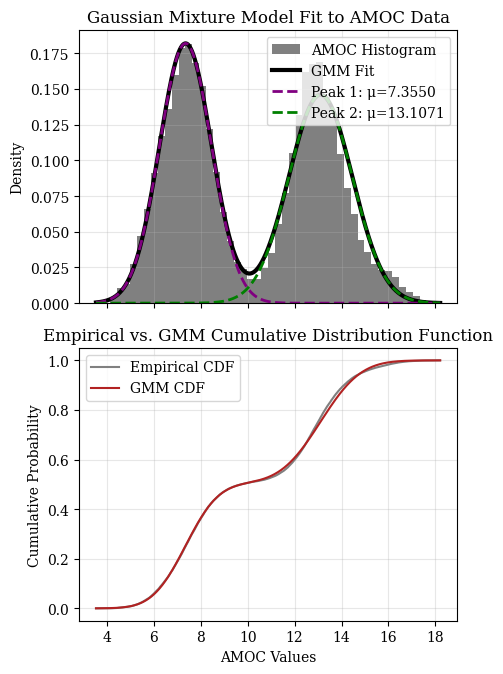

KS statistic = 0.02177
p-value = 0.00000


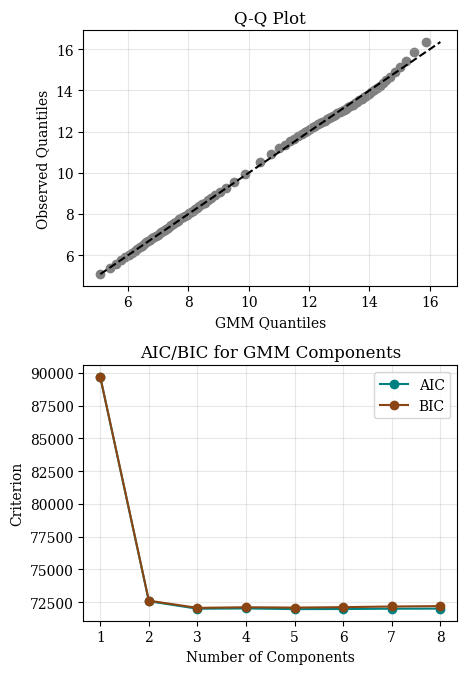

71976.83308200039 72073.04188833667
5 3
S: 5.385675657380123
Component 1: weight=0.513, mean=-7.856995e-06, std=3.348820e-06
Component 2: weight=0.487, mean=2.240914e-05, std=7.207533e-06


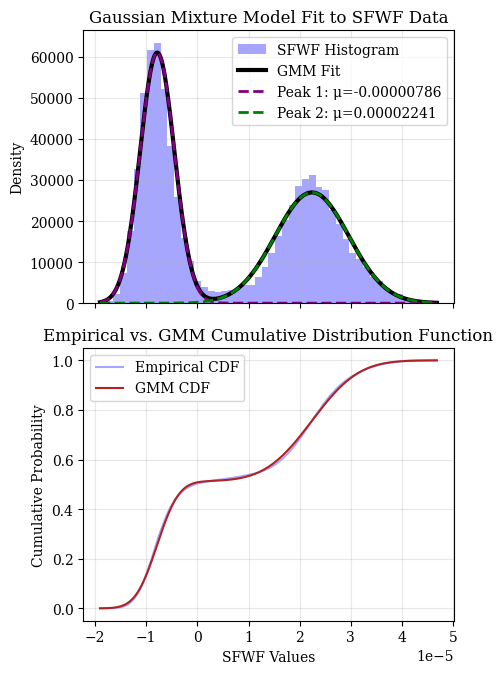

KS statistic = 0.01635
p-value = 0.00000


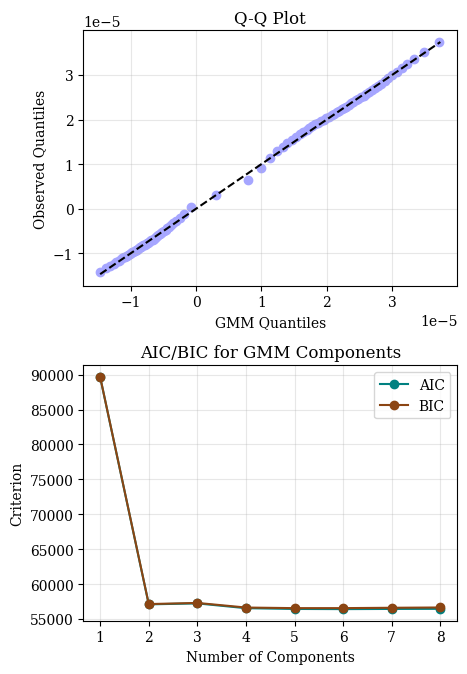

56412.10711331172 56552.10711928057
6 5
S: 7.242763947668861
Component 1: weight=0.490, mean=3.430170e-01, std=4.503435e-02
Component 2: weight=0.510, mean=6.048540e-01, std=2.420272e-02


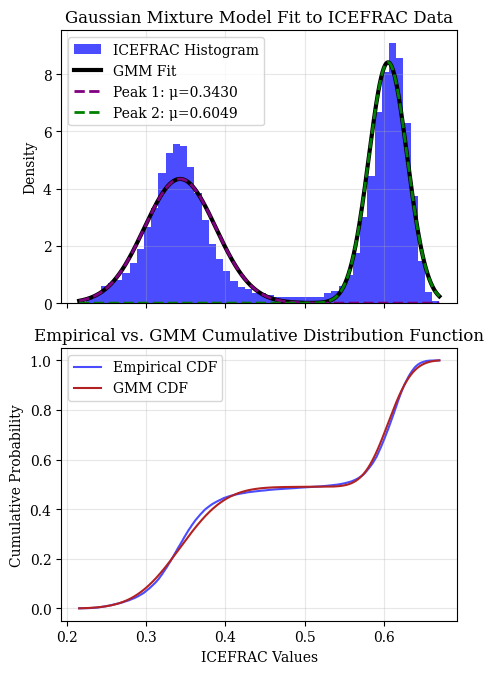

KS statistic = 0.02941
p-value = 0.00000


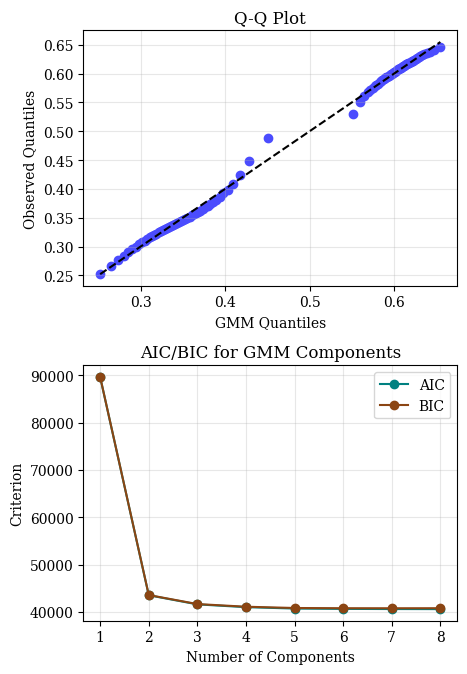

40592.76315559583 40775.51339007331
8 7
S: 4.780545643316634
Component 1: weight=0.520, mean=1.027697e+00, std=1.368247e-04
Component 2: weight=0.480, mean=1.028200e+00, std=5.846153e-05


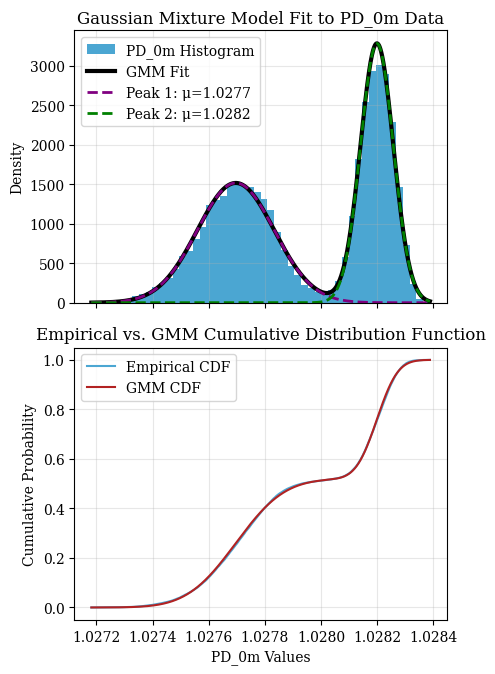

KS statistic = 0.00938
p-value = 0.00768


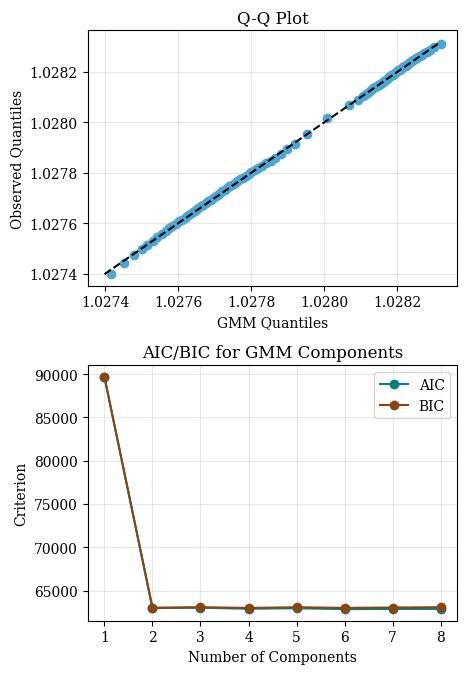

62850.84103457244 62987.48547606849
6 4
S: 4.1155321201906565
Component 1: weight=0.525, mean=1.028414e+00, std=7.916102e-05
Component 2: weight=0.475, mean=1.028673e+00, std=4.026831e-05


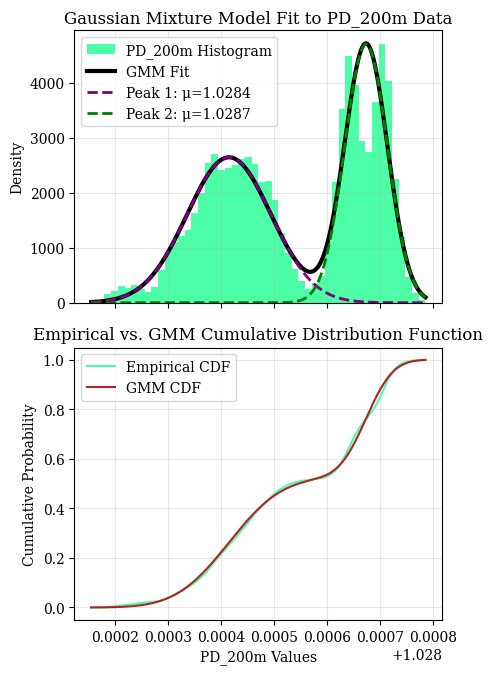

KS statistic = 0.03140
p-value = 0.00000


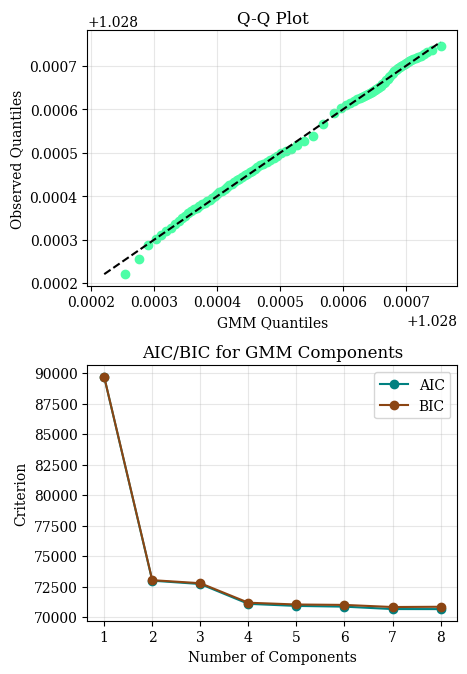

70648.80230417136 70820.32131076277
8 7


In [13]:
multi_gaussian_fit("AMOC", "gray", leg_pos = "upper right")
multi_gaussian_fit("SFWF", "#a6a6ff", precision = 8)
multi_gaussian_fit("ICEFRAC", "#4b4cfe")
multi_gaussian_fit("PD_0m", "#4ba6d2")
multi_gaussian_fit("PD_200m", "#4cfea6")

# **Variable Distribution Analyses**

Feature: MOC_30SAABW
Mean:    -7.3893
Std Dev: 1.6376
Min:     -14.2825
Max:     -0.7448
Feature: N_SALT
Mean:    -8444389840.0689
Std Dev: 1367106547.2219
Min:     -15090087936.0000
Max:     -3118387712.0000
Feature: Southern_Ocean_TAUX
Mean:    -0.0489
Std Dev: 0.0100
Min:     -0.0833
Max:     -0.0040


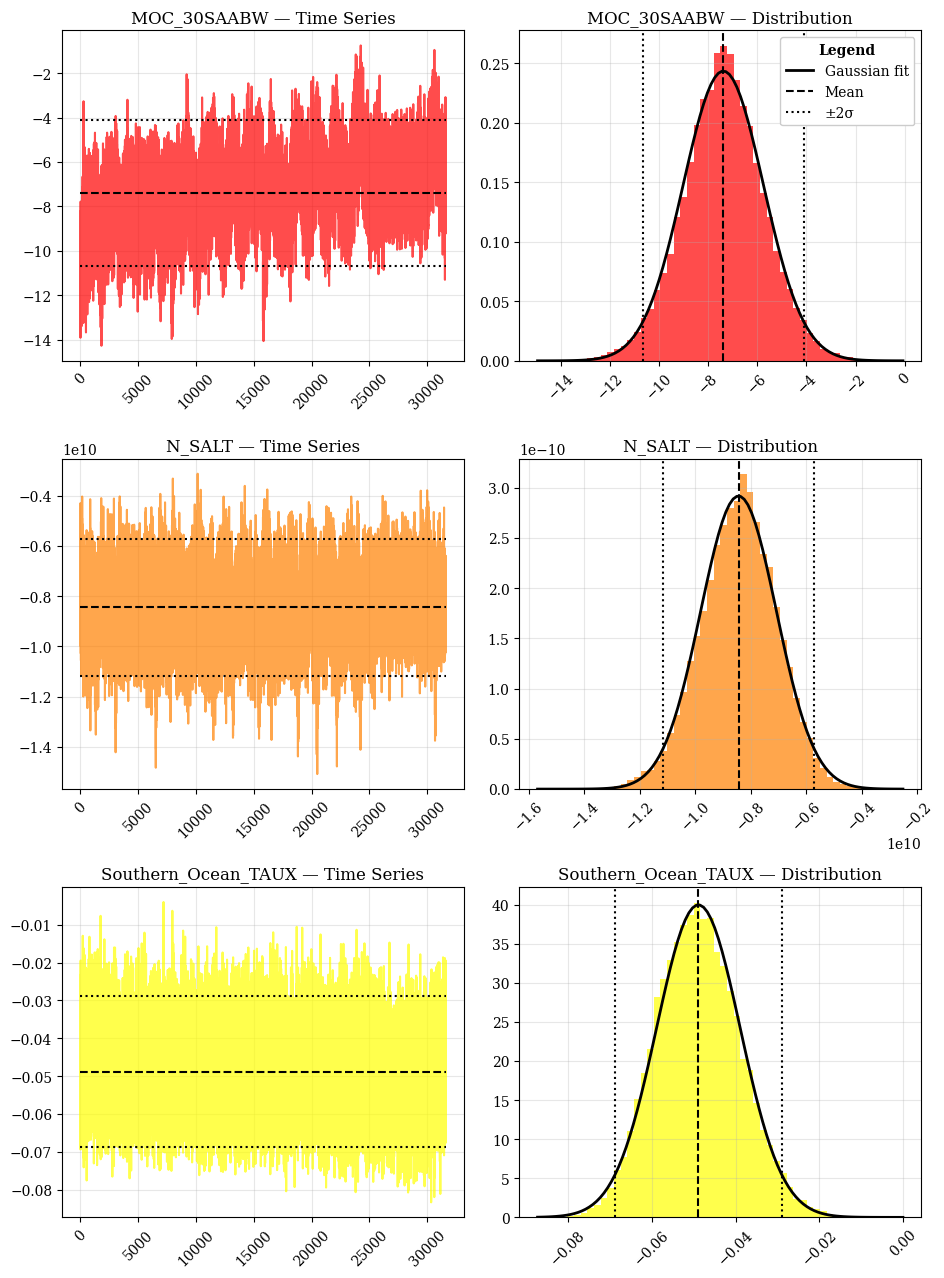

In [14]:
def feature_analysis_noise(gaussian_features = ["MOC_30SAABW", "N_SALT", "Southern_Ocean_TAUX"]):
    num_gaussian_features = len(gaussian_features)
    fig, axes = plt.subplots(num_gaussian_features, 2, figsize=(textwidth_in * 2,
                             textwidth_in * num_gaussian_features * 0.9))
    axes = axes.flatten()
    cmap_object = plt.colormaps['autumn']
    plot_colors = [cmap_object(i) for i in np.linspace(0, 1, num_gaussian_features)]
    legend_handles = []
    legend_labels  = []

    for j, feature_name in enumerate(gaussian_features):
        values = df[feature_name]
        mean_val = np.mean(values)
        std_val = np.std(values)

        ax_ts = axes[j * 2]
        ax_ts.plot(values, color=plot_colors[j], alpha=0.7)
        ax_ts.hlines(mean_val, 0, len(values), color='black', linestyle='--', linewidth=1.5)
        ax_ts.hlines(mean_val + 2*std_val, 0, len(values), color='black', linestyle='dotted')
        ax_ts.hlines(mean_val - 2*std_val, 0, len(values), color='black', linestyle='dotted')
        ax_ts.set_title(f'{feature_name} — Time Series')
        ax_ts.tick_params(axis='x', rotation=45)
        ax_ts.grid(alpha=0.3)

        leg = axes[1].legend(
            legend_handles, legend_labels,
            loc='upper right',
            frameon=True,
            fontsize=10,
            title='Legend',
            title_fontsize=10, framealpha=1
        )
        leg.get_title().set_fontweight('bold')

        ax_hist = axes[j * 2 + 1]
        ax_hist.hist(values, bins=50, color=plot_colors[j], alpha=0.7, density=True)
        xmin, xmax = ax_hist.get_xlim()
        x = np.linspace(xmin, xmax, 100)
        p = norm.pdf(x, mean_val, std_val)
        l1, = ax_hist.plot(x, p, 'k', linewidth=2, label='Gaussian fit')
        l2 = ax_hist.axvline(mean_val, color='black', linestyle='--', linewidth=1.5, label='Mean')
        l3 = ax_hist.axvline(mean_val + 2*std_val, color='black', linestyle='dotted', label=r'$± 2σ$')
        ax_hist.axvline(mean_val - 2*std_val, color='black', linestyle='dotted')
        ax_hist.set_title(f'{feature_name} — Distribution')
        ax_hist.tick_params(axis='x', rotation=45)
        ax_hist.grid(alpha=0.3)

        if j == 0:
            legend_handles = [l1, l2, l3]
            legend_labels  = ['Gaussian fit', 'Mean', '±2σ']

        print(f"Feature: {feature_name}")
        print(f"Mean:    {mean_val:.4f}")
        print(f"Std Dev: {std_val:.4f}")
        print(f"Min:     {np.min(values):.4f}")
        print(f"Max:     {np.max(values):.4f}")


    plt.tight_layout()
    plt.savefig('feature_plots_gaussian.pdf', bbox_inches='tight', dpi=300)
    plt.show()

feature_analysis_noise()

In [15]:
def feature_analysis(features = ["NAO", "SFWF", "SALT_500m"], cmap_object = plt.colormaps['cool']):
    num_features = len(features)
    fig, axes = plt.subplots(num_features, 2, figsize=(textwidth_in * 2, textwidth_in * num_features * 0.9))
    axes = axes.flatten()
    plot_colors = [cmap_object(i) for i in np.linspace(0, 1, num_features)]

    for j, feature_name in enumerate(features):
        values = df[feature_name]
        mean_val = np.mean(values)
        std_val = np.std(values)
        ax_ts = axes[j * 2]
        ax_ts.plot(values, color=plot_colors[j], alpha=0.7)
        ax_ts.set_title(f'{feature_name} — Time Series')
        ax_ts.tick_params(axis='x', rotation=45)
        ax_ts.grid(alpha=0.3)
        ax_hist = axes[j * 2 + 1]
        ax_hist.hist(values, bins=50, color=plot_colors[j], alpha=0.7, density=True)
        xmin, xmax = ax_hist.get_xlim()
        x = np.linspace(xmin, xmax, 100)
        p = norm.pdf(x, mean_val, std_val)
        ax_hist.set_title(f'{feature_name} — Distribution')
        ax_hist.tick_params(axis='x', rotation=45)
        ax_hist.grid(alpha=0.3)

        print(f"Feature: {feature_name}")
        print(f"  Mean:    {mean_val:.4f}")
        print(f"  Std Dev: {std_val:.4f}")
        print(f"  Min:     {np.min(values):.4f}")
        print(f"  Max:     {np.max(values):.4f}")


    plt.tight_layout()
    plt.savefig('feature_plots.pdf', bbox_inches='tight', dpi=300)
    plt.show()

Feature: NAO
  Mean:    -4.8653
  Std Dev: 359.4487
  Min:     -1417.7266
  Max:     1546.1016
Feature: SFWF
  Mean:    0.0000
  Std Dev: 0.0000
  Min:     -0.0000
  Max:     0.0000
Feature: SALT_500m
  Mean:    35.8607
  Std Dev: 0.0766
  Min:     35.6646
  Max:     36.0944


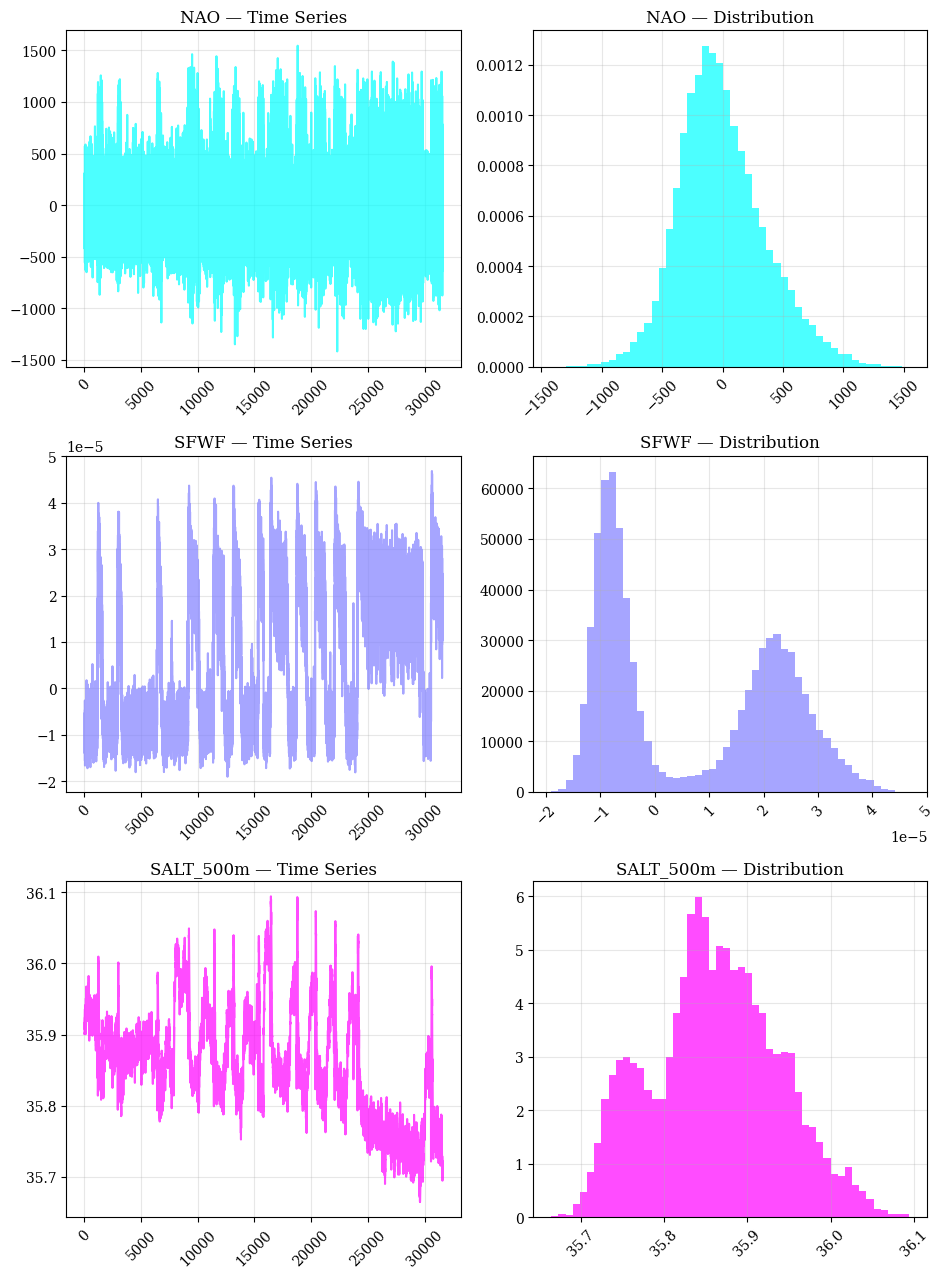

Feature: ICEFRAC
  Mean:    0.4766
  Std Dev: 0.1357
  Min:     0.2159
  Max:     0.6695
Feature: PD_0m
  Mean:    1.0279
  Std Dev: 0.0003
  Min:     1.0272
  Max:     1.0284
Feature: PD_200m
  Mean:    1.0285
  Std Dev: 0.0001
  Min:     1.0282
  Max:     1.0288


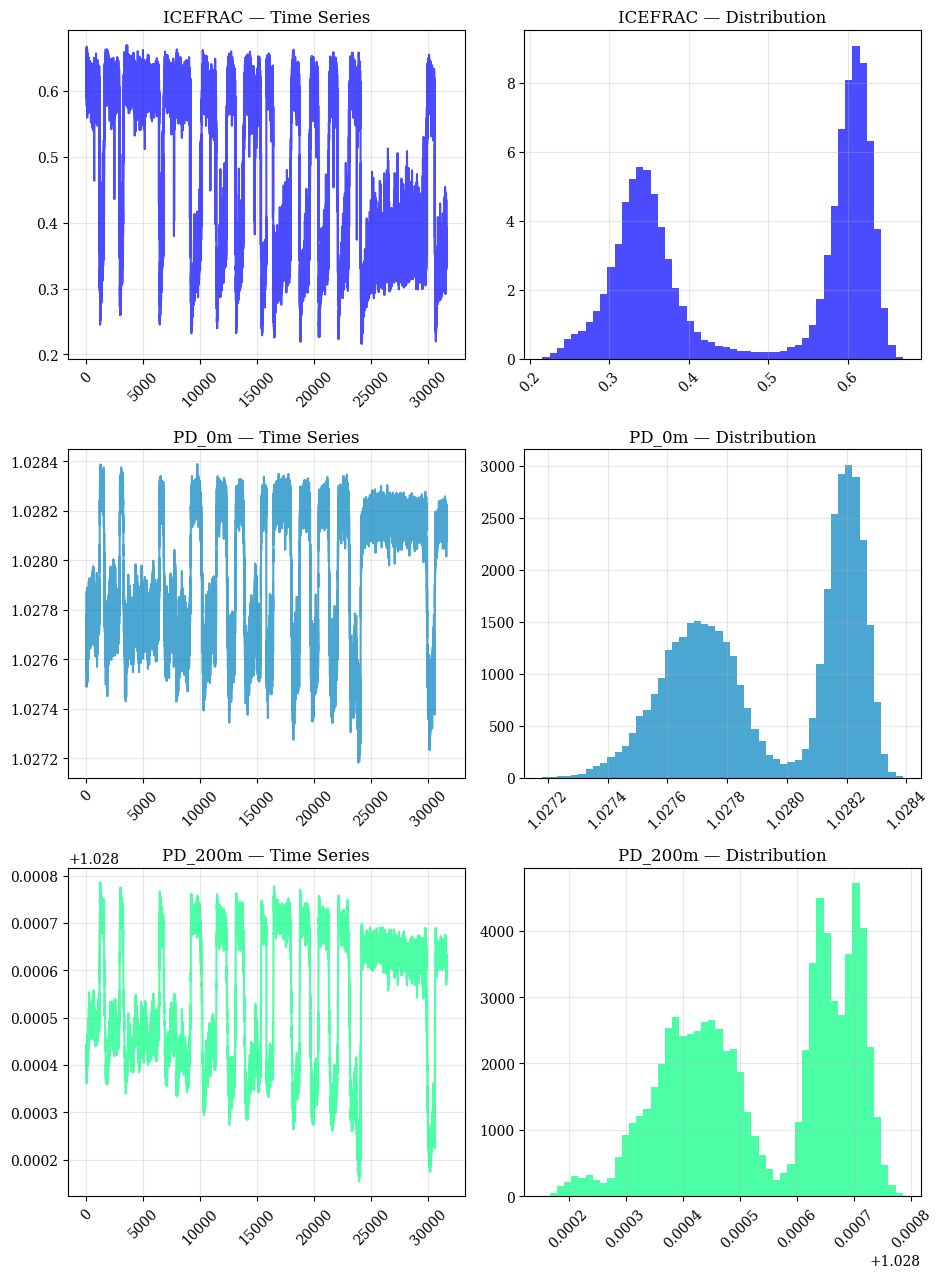

In [16]:
feature_analysis(features = ["NAO", "SFWF", "SALT_500m"], cmap_object = plt.colormaps['cool'])
feature_analysis(features = ["ICEFRAC", "PD_0m", "PD_200m"], cmap_object = plt.colormaps['winter'])

# **Quantitative Analysis**

  **Correlation**

In [19]:
all_features = ["AMOC", "SFWF", "PD_200m", "SALT_500m", "NAO", "ICEFRAC", "PD_0m", "MOC_30SAABW", "N_SALT", "Southern_Ocean_TAUX"]
df = pd.read_csv("CombinedDatasetLongUnsmooth.csv")[all_features]

def lag_1_corr_matrix():
    lag = 1
    corr_matrix = pd.DataFrame(index = all_features, columns = all_features, dtype=float)

    for target in all_features:
        for feat in all_features:
            if feat == target:
                corr_matrix.loc[feat, target] = 1.0
            else:
                corr_matrix.loc[feat, target] = df[feat].iloc[:-lag].corr(df[target].iloc[lag:])

    fig, ax = plt.subplots(figsize=(10, 8))
    hm = sns.heatmap(corr_matrix.astype(float), annot = True, fmt = ".2f", cmap = "RdBu_r",
                center = 0, vmin = -1, vmax = 1, ax = ax, linewidths = 0.5)

    cbar = hm.collections[0].colorbar
    cbar.set_label('Correlation', fontsize=12)

    amoc_idx = all_features.index("AMOC")
    rect = patches.Rectangle((amoc_idx, 0), 1, len(all_features), linewidth = 2, edgecolor = 'green', facecolor = 'none')
    ax.add_patch(rect)
    ax.set_title("Lag-1 Cross-Correlation Matrix")
    ax.set_xlabel("Target Y(t+1)")
    ax.set_ylabel("Predictor X(t)")
    plt.tight_layout()
    plt.savefig("lag1_correlation_matrix.pdf", dpi = 300)
    plt.show()

def lag_peak_correlation():
    lags_range = range(1, 7500)
    y_target = df["AMOC"]

    features_for_lag_analysis = [f for f in all_features if f != 'AMOC']
    max_correlations = []
    best_lags = []

    for feat in features_for_lag_analysis:
        cross_corr = ccf(df[feat], y_target, nlags=max(lags_range))
        abs_cross_corr = np.abs(cross_corr[1:max(lags_range)+1])
        if len(abs_cross_corr) > 0:
            max_corr_value = np.max(abs_cross_corr)
            best_lag = np.argmax(abs_cross_corr) + 1
        else:
            max_corr_value = 0.0
            best_lag = 0

        max_correlations.append(max_corr_value)
        best_lags.append(best_lag)

    lag_analysis_df = pd.DataFrame({
        'Feature': features_for_lag_analysis,
        'Max_Correlation': max_correlations,
        'Best_Lag': best_lags
    })

    lag_analysis_df = lag_analysis_df.sort_values(by='Max_Correlation', ascending=False)
    print(max_correlations)
    print(best_lags)

    plt.figure(figsize=(12, 6))
    sns.barplot(x='Feature', y='Max_Correlation', data=lag_analysis_df, palette='plasma', hue='Feature', legend=False)
    plt.title('Maximum Absolute Cross-Correlation with AMOC')
    plt.xlabel('Feature')
    plt.ylabel('Maximum Absolute Cross-Correlation')
    plt.xticks(rotation=45, ha='right')
    plt.grid(True, alpha=0.3)
    palette = sns.color_palette('plasma', n_colors=len(lag_analysis_df))
    legend_handles = []
    legend_labels = []

    for i, (index, row) in enumerate(lag_analysis_df.iterrows()):
        label = f"r={row['Max_Correlation']:.2f}, Lag={row['Best_Lag']}"
        legend_handles.append(patches.Patch(color=palette[i], label=label))
        legend_labels.append(label)

    plt.legend(handles=legend_handles, labels=legend_labels, title='Feature Details', loc='upper right')

    plt.tight_layout()
    plt.savefig("max_cross_correlation_with_lag.pdf", dpi=300)
    plt.show()

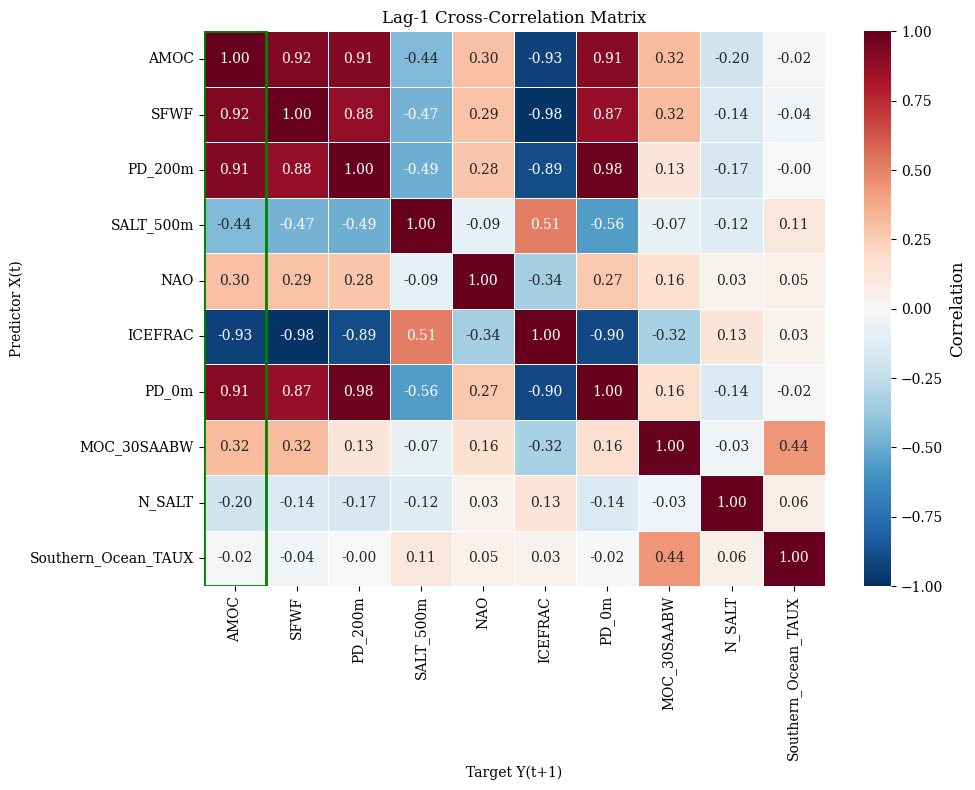

[np.float64(0.9203555046730428), np.float64(0.9151797054556848), np.float64(0.6829131065835483), np.float64(0.29244877527999497), np.float64(0.9337261954064433), np.float64(0.9119721880992834), np.float64(0.3231115786689722), np.float64(0.23141249513916884), np.float64(0.1008005321991118)]
[np.int64(2), np.int64(4), np.int64(161), np.int64(5), np.int64(2), np.int64(3), np.int64(1), np.int64(515), np.int64(730)]


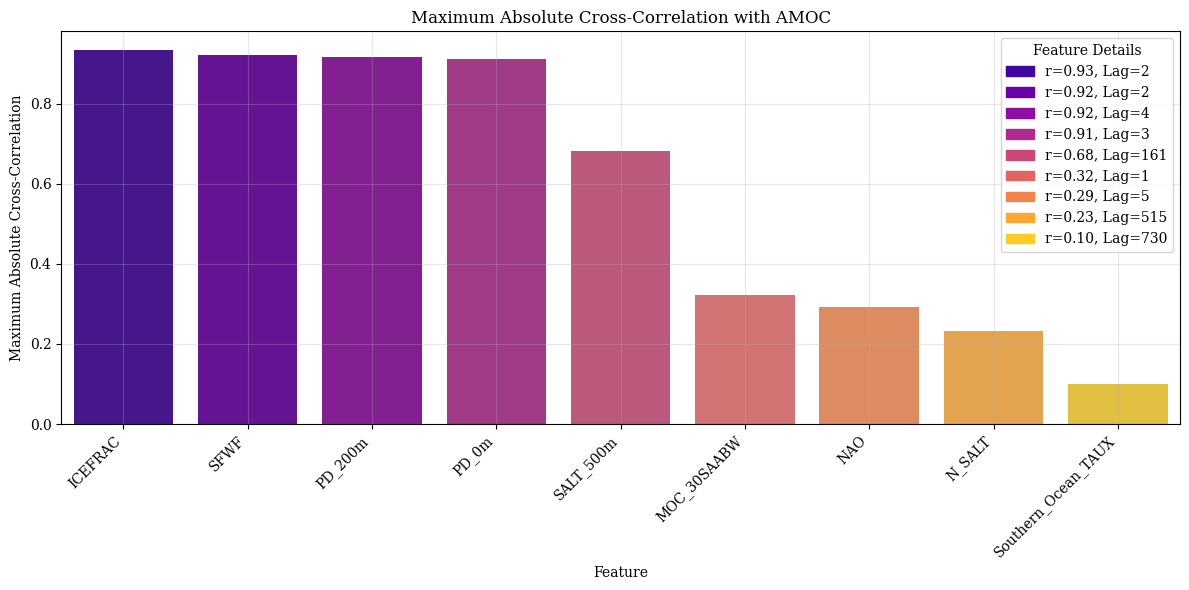

In [20]:
lag_1_corr_matrix()
lag_peak_correlation()

**MI Score**

In [25]:
def MI_score():
    features_to_test = ["SFWF", "PD_200m", "SALT_500m", "NAO", "ICEFRAC", "PD_0m", "MOC_30SAABW", "N_SALT", "Southern_Ocean_TAUX"]
    X = df[features_to_test].values[:-1]
    y = df["AMOC"].values[1:]
    mi_scores = mutual_info_regression(X, y, random_state=18)
    for feat, score in sorted(zip(features_to_test, mi_scores),
                              key=lambda x: -x[1]):
        print(f"  {feat}: MI = {score:.4f}")

In [26]:
MI_score()

  PD_200m: MI = 0.8549
  ICEFRAC: MI = 0.7986
  PD_0m: MI = 0.7823
  SFWF: MI = 0.7637
  SALT_500m: MI = 0.4833
  NAO: MI = 0.1087
  MOC_30SAABW: MI = 0.0702
  N_SALT: MI = 0.0511
  Southern_Ocean_TAUX: MI = 0.0048


**VIF**

In [27]:
def vif_analysis():
    vif_features = ["SFWF", "PD_200m", "ICEFRAC", "PD_0m", "SALT_500m"]
    X = df[vif_features].dropna().values
    for i, feat in enumerate(vif_features):
        vif = variance_inflation_factor(X, i)
        print(f"{feat}: VIF = {vif:.2f}")

In [28]:
vif_analysis()

SFWF: VIF = 31.28
PD_200m: VIF = 288493731.69
ICEFRAC: VIF = 446.31
PD_0m: VIF = 280063012.78
SALT_500m: VIF = 354122.16


**Autocorrelation Timescale**

In [29]:
def autocorrelation_timescale():
    for feat in ["AMOC", "SFWF", "PD_200m", "ICEFRAC"]:
        a = acf(df[feat].dropna(), nlags=500, fft=True)
        timescale = next((i for i, v in enumerate(a) if v < 0.37), 50)
        print(f"{feat}: autocorrelation timescale ~{timescale} steps")

In [30]:
autocorrelation_timescale()

AMOC: autocorrelation timescale ~301 steps
SFWF: autocorrelation timescale ~343 steps
PD_200m: autocorrelation timescale ~306 steps
ICEFRAC: autocorrelation timescale ~362 steps


**Spearman Rank**

In [31]:
def spearman_corr():
    for feat in all_features:
        if feat == "AMOC":
            continue
        pearson  = df[feat].iloc[:-1].corr(df["AMOC"].iloc[1:])
        spearman = spearmanr(df[feat].iloc[:-1], df["AMOC"].iloc[1:])[0]
        diff = abs(pearson - spearman)
        print(f"{feat}: Pearson={pearson:.3f}  Spearman={spearman:.4f}  diff={diff:.3f}")

In [32]:
spearman_corr()

SFWF: Pearson=0.923  Spearman=0.8401  diff=0.083
PD_200m: Pearson=0.914  Spearman=0.8793  diff=0.035
SALT_500m: Pearson=-0.438  Spearman=-0.4500  diff=0.012
NAO: Pearson=0.298  Spearman=0.2178  diff=0.080
ICEFRAC: Pearson=-0.933  Spearman=-0.8529  diff=0.081
PD_0m: Pearson=0.912  Spearman=0.8536  diff=0.058
MOC_30SAABW: Pearson=0.320  Spearman=0.2892  diff=0.031
N_SALT: Pearson=-0.200  Spearman=-0.1721  diff=0.028
Southern_Ocean_TAUX: Pearson=-0.017  Spearman=-0.0217  diff=0.005


**Distance Correlation**

In [35]:
def distance_corr():
    for feat in all_features:
        if feat == "AMOC":
            continue
        dc = distance_correlation(df[feat].iloc[:-1].values, df["AMOC"].iloc[1:].values)
        print(f"{feat}: {dc:.4f}")

In [36]:
distance_corr()

SFWF: 0.9356
PD_200m: 0.9407
SALT_500m: 0.5996
NAO: 0.3188
ICEFRAC: 0.9456
PD_0m: 0.9436
MOC_30SAABW: 0.2720
N_SALT: 0.1474
Southern_Ocean_TAUX: 0.0501
